# CS 7389H, Lecture 02: Supervised Learning, Worked Examples

This notebook is the companion to `2_1_Supervised_Learning.ipynb` from *Understanding Deep Learning* (Prince, Chapter 2).

That notebook makes one main point: with a 1D linear model and twelve toy points, you can see the loss surface in its entirety and find the best parameters by eye. Everything is visible because nothing is hidden.

This notebook asks what survives when the data is real. We keep the exact same model and the exact same loss, swap the twelve toy points for a real dataset, and then push on the three ideas the lecture introduced but could not demonstrate with a straight line:

1. **Gradient descent** actually running, including the moment it fails.
2. **Train / validate / test** as three lines of code, and why the test set is opened once.
3. **Overfitting** as something you measure, not something you are told about.

We finish with a classifier that has no parameters at all, which is a useful way to see what "learning the parameters" was buying us.

**Everything here is NumPy, Matplotlib, and scikit-learn.** No deep learning yet. The point is that the vocabulary from the lecture (model, parameters, loss, training, testing) describes these small models exactly as well as it will describe a transformer, and it is much easier to see it here.

---
## 0. Setup

If you are running this on Colab, upload the `data/` folder alongside the notebook, or mount your Drive. The loader below checks a few likely locations and falls back to scikit-learn's built-in copy of Iris.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score

# Prince's colour palette, so these figures match the lecture slides.
ORANGE = '#D18362'   # data points
ODGE   = '#773C23'   # point edges
TEAL   = '#00847B'   # the best fit
LTEAL  = '#8FDAD3'   # intermediate / secondary fits
GREY   = '#B4B4B4'   # contours

plt.rcParams.update({
    'mathtext.fontset': 'cm',
    'axes.linewidth': 0.9,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'axes.unicode_minus': False,
    'figure.dpi': 110,
})

rng = np.random.default_rng(0)   # one seed for the whole notebook

def scatter(ax, x, y, **kw):
    """Data points in the lecture's house style."""
    kw.setdefault('ms', 5)
    ax.plot(x, y, 'o', mfc=ORANGE, mec=ODGE, mew=0.7, ls='none', **kw)

In [2]:
def find_data(filename):
    """Locate a CSV whether we are in the lecture folder, the repo root, or Colab."""
    candidates = [
        os.path.join('data', filename),
        os.path.join('..', 'data', filename),
        filename,
    ]
    for p in candidates:
        if os.path.exists(p):
            return p
    raise FileNotFoundError(
        f"Could not find {filename}. Looked in: {candidates}\n"
        f"On Colab, upload the data folder first (Files pane, or files.upload())."
    )

ads = pd.read_csv(find_data('advertising_data.csv'))
print(ads.shape)
ads.head()

(200, 4)


,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


---
## 1. The same model, on data that did not come from a textbook

The **advertising dataset** records, for 200 markets, how much was spent on TV, radio, and newspaper advertising (in thousands of dollars) and how many units were sold (in thousands).

We are going to use exactly one input, TV spend, and predict sales. That gives us the same 1D problem as the lecture:

$$y = \mathrm{f}[x, \boldsymbol\phi] = \phi_0 + \phi_1 x$$

with the same least squares loss:

$$L[\boldsymbol\phi] = \sum_{i=1}^{I} \big(\phi_0 + \phi_1 x_i - y_i\big)^2$$

Nothing about the mathematics changes. Only the numbers do.

In [3]:
ads.describe().round(2)

,TV,Radio,Newspaper,Sales
count,200.00,200.00,200.00,200.00
mean,147.04,23.26,30.55,15.13
std,85.85,14.85,21.78,5.28
min,0.70,0.00,0.30,1.60
25%,74.38,9.98,12.75,11.00
50%,149.75,22.90,25.75,16.00
75%,218.82,36.52,45.10,19.05
max,296.40,49.60,114.00,27.00


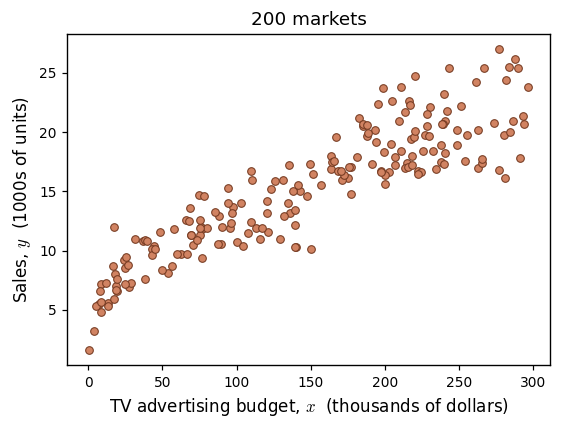

In [4]:
x_all = ads['TV'].to_numpy(dtype=float)
y_all = ads['Sales'].to_numpy(dtype=float)

fig, ax = plt.subplots(figsize=(5.2, 4))
scatter(ax, x_all, y_all)
ax.set_xlabel('TV advertising budget, $x$  (thousands of dollars)')
ax.set_ylabel('Sales, $y$  (1000s of units)')
ax.set_title('200 markets')
plt.tight_layout(); plt.show()

**Pause before reading on.** Two questions worth answering out loud:

1. Does a straight line look like the right model here? Look at the left edge and the right edge of the cloud.
2. The vertical spread grows as you move right. The lecture's loss function treats every point's error identically. Is that reasonable?

Neither observation stops us from fitting a line. Both will come back later in the course, the first as *model capacity* (Chapters 3 and 4) and the second as *how you choose a loss function* (Chapter 5).

### 1.1 The loss surface, for real data

The lecture showed the loss surface for the toy problem as a heat map over $\phi_0$ and $\phi_1$: a long, curved valley with a single lowest point. Let us draw the same picture for the advertising data.

The only thing we change is the range of the axes, because sales and TV budgets live on different scales than the toy numbers did.

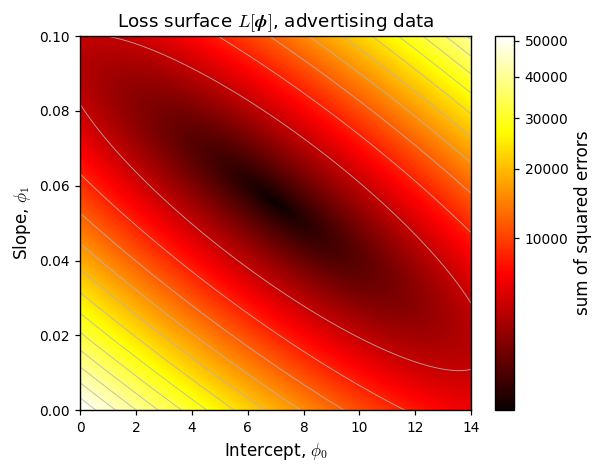

Lowest point on this grid: L = 1,043.6


In [5]:
def total_loss(phi0, phi1, x, y):
    """Sum of squared deviations, exactly the L[phi] from the lecture."""
    return np.sum((phi0 + phi1 * x - y) ** 2)

# Grid over plausible parameter values.
p0_grid = np.linspace(0.0, 14.0, 300)
p1_grid = np.linspace(0.0, 0.10, 300)
P0, P1 = np.meshgrid(p0_grid, p1_grid)

# Vectorised: accumulate one data point at a time over the whole grid.
Z = np.zeros_like(P0)
for xi, yi in zip(x_all, y_all):
    Z += (P0 + P1 * xi - yi) ** 2

from matplotlib.colors import PowerNorm

fig, ax = plt.subplots(figsize=(5.6, 4.4))
im = ax.imshow(Z, origin='lower', aspect='auto', cmap='hot',
               extent=[p0_grid[0], p0_grid[-1], p1_grid[0], p1_grid[-1]],
               norm=PowerNorm(gamma=0.45, vmin=Z.min(), vmax=Z.max()))
ax.contour(P0, P1, Z, levels=14, colors=[GREY], linewidths=0.6, alpha=0.85)
ax.set_xlabel('Intercept, $\\phi_0$')
ax.set_ylabel('Slope, $\\phi_1$')
ax.set_title('Loss surface $L[\\boldsymbol{\\phi}]$, advertising data')
fig.colorbar(im, ax=ax, label='sum of squared errors')
plt.tight_layout(); plt.show()

print(f"Lowest point on this grid: L = {Z.min():,.1f}")

Same shape as the toy problem: one long diagonal valley, one minimum, no other basins. This is what **convex** looks like. The lecture's promise was that for a linear model with a least squares loss, this is always the picture, and that promise is about to expire: from Chapter 3 onward the surface will look nothing like this.

Notice the valley runs at an angle. That means $\phi_0$ and $\phi_1$ are correlated: if you raise the intercept, you can compensate by lowering the slope and barely change the loss. That diagonal is going to cause trouble in the next section.

### 1.2 The answer, computed directly

For this particular model and this particular loss, we do not need to search at all. Least squares has a closed-form solution, and scikit-learn will hand it to us.

phi_0 = 6.9748
phi_1 = 0.0555
L[phi*] = 1,043.55


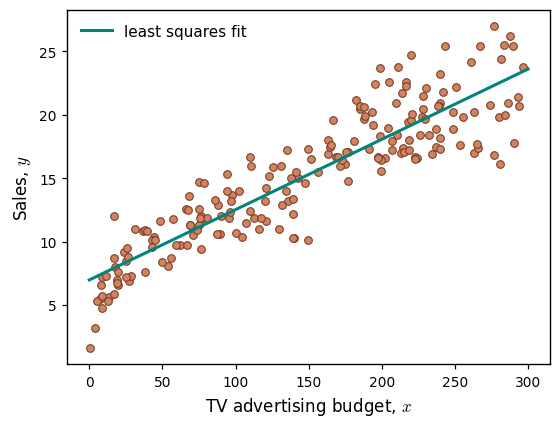

In [6]:
lin = LinearRegression().fit(x_all.reshape(-1, 1), y_all)
phi0_star, phi1_star = float(lin.intercept_), float(lin.coef_[0])

print(f"phi_0 = {phi0_star:.4f}")
print(f"phi_1 = {phi1_star:.4f}")
print(f"L[phi*] = {total_loss(phi0_star, phi1_star, x_all, y_all):,.2f}")

fig, ax = plt.subplots(figsize=(5.2, 4))
scatter(ax, x_all, y_all)
xs = np.linspace(0, 300, 200)
ax.plot(xs, phi0_star + phi1_star * xs, color=TEAL, lw=2, label='least squares fit')
ax.set_xlabel('TV advertising budget, $x$')
ax.set_ylabel('Sales, $y$')
ax.legend(frameon=False)
plt.tight_layout(); plt.show()

Read the parameters as claims about the world. $\phi_1 \approx 0.056$ says that every extra \$1000 of TV budget is associated with roughly 56 extra units sold. $\phi_0 \approx 6.97$ says a market with no TV advertising still sells about 7000 units.

Note the phrase "is associated with". The model was fitted to observational data, so it describes a correlation. Whether spending the money *causes* the sales is a different question that no loss function can answer.

**This closed form is the exception, not the rule.** It exists because the model is linear in its parameters and the loss is squared error. Break either condition, which every neural network in this course does, and there is no formula. That is why the next section matters.

---
## 2. Gradient descent, and the first time it fails

The lecture walked downhill by hand. Here is the same procedure in code. The rule is the one from the slides:

$$\boldsymbol\phi \leftarrow \boldsymbol\phi - \alpha \frac{\partial L}{\partial \boldsymbol\phi}$$

For the mean squared loss $L = \frac{1}{I}\sum_i (\phi_0 + \phi_1 x_i - y_i)^2$ the derivatives are:

$$\frac{\partial L}{\partial \phi_0} = \frac{2}{I}\sum_i r_i, \qquad \frac{\partial L}{\partial \phi_1} = \frac{2}{I}\sum_i r_i x_i, \qquad r_i = \phi_0 + \phi_1 x_i - y_i$$

We use the *mean* rather than the sum so that the step size does not depend on how many data points we happen to have.

In [7]:
def gradient_descent(x, y, lr, n_steps, phi=(0.0, 0.0)):
    """Plain full-batch gradient descent. Returns the parameter path and the loss at each step."""
    phi0, phi1 = phi
    path, losses = [(phi0, phi1)], []
    I = len(x)
    for _ in range(n_steps):
        r = phi0 + phi1 * x - y
        losses.append(np.mean(r ** 2))
        g0 = 2.0 * np.mean(r)
        g1 = 2.0 * np.mean(r * x)
        phi0 -= lr * g0
        phi1 -= lr * g1
        path.append((phi0, phi1))
    r = phi0 + phi1 * x - y
    losses.append(np.mean(r ** 2))
    return np.array(path), np.array(losses)

path, losses = gradient_descent(x_all, y_all, lr=0.01, n_steps=10)
for k, (p, l) in enumerate(zip(path, losses)):
    print(f"step {k}:  phi = ({p[0]:12.4g}, {p[1]:12.4g})   L = {l:12.4g}")

step 0:  phi = (           0,            0)   L =        256.7
step 1:  phi = (      0.3026,        52.63)   L =    7.994e+07
step 2:  phi = (      -154.2,   -3.038e+04)   L =    2.672e+13
step 3:  phi = (   8.918e+04,    1.756e+07)   L =     8.93e+18
step 4:  phi = (  -5.156e+07,   -1.015e+10)   L =    2.985e+24
step 5:  phi = (   2.981e+10,    5.869e+12)   L =    9.976e+29
step 6:  phi = (  -1.723e+13,   -3.393e+15)   L =    3.334e+35
step 7:  phi = (   9.962e+15,    1.962e+18)   L =    1.114e+41
step 8:  phi = (  -5.759e+18,   -1.134e+21)   L =    3.725e+46
step 9:  phi = (    3.33e+21,    6.557e+23)   L =    1.245e+52
step 10:  phi = (  -1.925e+24,   -3.791e+26)   L =    4.161e+57


It exploded. Not "converged slowly", not "landed in the wrong place": the numbers ran off to infinity within a few steps.

This is worth sitting with, because it is the single most common way a training run fails, and it has nothing to do with the model being wrong.

**The diagnosis.** TV budgets run from about 0.7 to 296. Sales run from about 1.6 to 27. So $\partial L/\partial \phi_1$, which is an average of $r_i x_i$, is roughly a hundred times larger than $\partial L/\partial \phi_0$, which averages $r_i$ alone. A single step size $\alpha$ has to serve both. Any $\alpha$ small enough to keep $\phi_1$ stable leaves $\phi_0$ crawling, and any $\alpha$ large enough to move $\phi_0$ sends $\phi_1$ past the valley and up the far wall, further out each time.

That diagonal valley we noticed in the loss surface is exactly this problem drawn as a picture.

**The fix** is to put the input on a comparable scale to the output. Standardising is the usual choice:

$$\tilde{x}_i = \frac{x_i - \mu_x}{\sigma_x}$$

In [8]:
mu, sigma = x_all.mean(), x_all.std()
x_std = (x_all - mu) / sigma

path, losses = gradient_descent(x_std, y_all, lr=0.1, n_steps=60)
print(f"final phi = ({path[-1][0]:.4f}, {path[-1][1]:.4f})")
print(f"final MSE = {losses[-1]:.4f}")

# Convert back to the original units so we can compare with the closed-form answer.
b0, b1 = path[-1]
print(f"\nin original units:  phi_0 = {b0 - b1 * mu / sigma:.4f},  phi_1 = {b1 / sigma:.4f}")
print(f"closed form:        phi_0 = {phi0_star:.4f},  phi_1 = {phi1_star:.4f}")

final phi = (15.1305, 4.7500)
final MSE = 5.2177

in original units:  phi_0 = 6.9748,  phi_1 = 0.0555
closed form:        phi_0 = 6.9748,  phi_1 = 0.0555


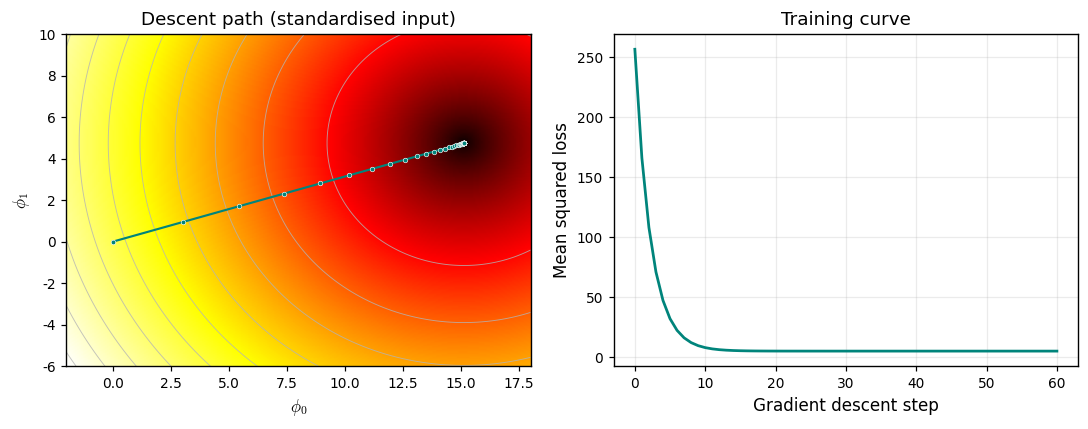

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Left: the descent path on the loss surface, in standardised coordinates.
g0 = np.linspace(-2, 18, 250)
g1 = np.linspace(-6, 10, 250)
G0, G1 = np.meshgrid(g0, g1)
ZS = np.zeros_like(G0)
for xi, yi in zip(x_std, y_all):
    ZS += (G0 + G1 * xi - yi) ** 2
ZS /= len(x_std)

ax = axes[0]
ax.imshow(ZS, origin='lower', aspect='auto', cmap='hot',
          extent=[g0[0], g0[-1], g1[0], g1[-1]],
          norm=PowerNorm(gamma=0.4, vmin=ZS.min(), vmax=ZS.max()))
ax.contour(G0, G1, ZS, levels=12, colors=[GREY], linewidths=0.6, alpha=0.8)
ax.plot(path[:, 0], path[:, 1], '-o', color=TEAL, ms=3, lw=1.4, mec='w', mew=0.4)
ax.set_xlabel('$\\phi_0$'); ax.set_ylabel('$\\phi_1$')
ax.set_title('Descent path (standardised input)')

# Right: the loss as a function of step number.
ax = axes[1]
ax.plot(losses, color=TEAL, lw=1.8)
ax.set_xlabel('Gradient descent step')
ax.set_ylabel('Mean squared loss')
ax.set_title('Training curve')
ax.grid(alpha=0.25)

plt.tight_layout(); plt.show()

Look at the left panel. In these coordinates the valley is almost circular, and the path runs more or less straight to the bottom. That is the whole effect of standardising: the two parameters now have comparable influence on the loss, so a single step size suits both, and the pathological zig-zag from before has nowhere to come from.

The right panel is the plot you will stare at for the rest of the course. Steep collapse, then a long flat tail. Once you are on that tail, extra steps buy almost nothing.

Two things to carry forward:

- **Feature scaling is not a detail.** Every deep network in this course depends on it, and the modern version of this fix, applied to the intermediate values inside a network rather than just its inputs, is called *batch normalisation* (Chapter 11).
- **We reached the same answer the closed form gave us**, to four decimal places. That is the last time we will be able to check. From Chapter 3 onward, gradient descent is not one option among several; it is the only one, and there is no independent answer to compare it against.

**Try it yourself:** change `lr` to 0.5, then 1.0, then 0.01, and rerun. Find roughly where the boundary between converging and diverging sits, and see how slow the small value is.

---
## 3. Train, validate, test

Everything above fitted the model to all 200 markets and then reported the loss on those same 200 markets. The lecture called that number what it is: a measure of how well we *memorised*, not of how well we will *do*.

The correction is procedural, and it is three lines of code.

In [10]:
# First split off a test set and then, from what remains, a validation set.
x_tr_val, x_test, y_tr_val, y_test = train_test_split(
    x_all, y_all, test_size=0.20, random_state=0)
x_train, x_val, y_train, y_val = train_test_split(
    x_tr_val, y_tr_val, test_size=0.25, random_state=0)   # 0.25 of 80% = 20% of the whole

print(f"train:      {len(x_train):3d} markets  ({len(x_train)/len(x_all):.0%})")
print(f"validation: {len(x_val):3d} markets  ({len(x_val)/len(x_all):.0%})")
print(f"test:       {len(x_test):3d} markets  ({len(x_test)/len(x_all):.0%})")

train:      120 markets  (60%)
validation:  40 markets  (20%)
test:        40 markets  (20%)


The three sets answer three different questions:

| Set | Used for | How often you look |
|---|---|---|
| **Train** | choosing the parameters $\boldsymbol\phi$ | constantly, that is what fitting is |
| **Validation** | choosing everything *else*: model, capacity, learning rate | often, once per candidate |
| **Test** | estimating performance on data you have never seen | **once**, at the very end |

The rule about the test set is not bureaucratic fussiness. The moment you use a number to make a decision, that number stops being an unbiased estimate of anything. If you try forty models and report the best test score, you have not measured performance; you have measured the largest of forty noisy numbers.

`random_state=0` fixes the shuffle so this notebook is reproducible. In real work, be aware that a single split is itself noisy. Change the seed below and watch the test score move.

In [11]:
lin = LinearRegression().fit(x_train.reshape(-1, 1), y_train)

for name, xs, ys in [('train', x_train, y_train),
                     ('validation', x_val, y_val),
                     ('test', x_test, y_test)]:
    pred = lin.predict(xs.reshape(-1, 1))
    print(f"{name:>11}:  MSE = {mean_squared_error(ys, pred):6.3f}   R^2 = {r2_score(ys, pred):5.3f}")

      train:  MSE =  4.931   R^2 = 0.795
 validation:  MSE =  4.732   R^2 = 0.853
       test:  MSE =  6.679   R^2 = 0.800


For a straight line the three numbers come out close together. A model this simple cannot memorise 120 points even if it wanted to, so there is nothing for the held-out data to catch it doing.

That is not a general fact. It is a fact about *this model*, and the next section breaks it deliberately.

---
## 4. Capacity, and the point where more model stops helping

### 4.1 A model with a capacity dial: $k$-nearest neighbours

$k$-nearest neighbours regression predicts the value at a new point by averaging the $y$ values of the $k$ closest training points. There are no $\phi$ to fit at all. The "training" step is just storing the data.

What it does have is $k$, and $k$ controls capacity directly:

- $k = 1$: predict the single nearest neighbour's value. The model passes through every training point exactly.
- $k$ large: average over a wide neighbourhood. The prediction becomes smooth and eventually flat.

Watch what that does to the training score and the validation score at the same time.

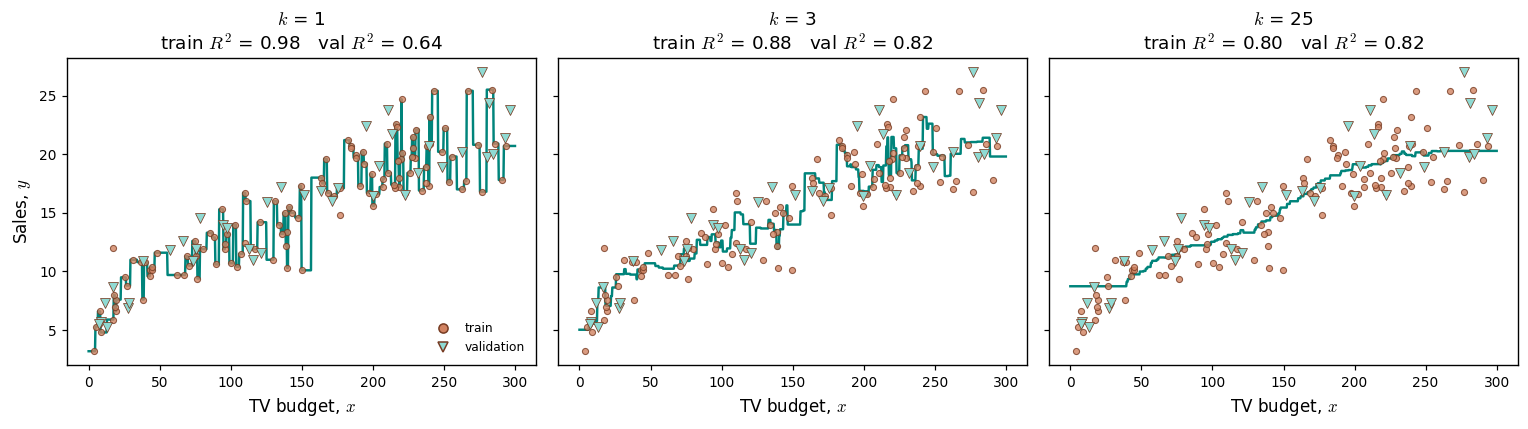

In [12]:
line = np.linspace(0, 300, 1000).reshape(-1, 1)

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for k, ax in zip([1, 3, 25], axes):
    reg = KNeighborsRegressor(n_neighbors=k).fit(x_train.reshape(-1, 1), y_train)
    ax.plot(line, reg.predict(line), color=TEAL, lw=1.6, zorder=1)
    scatter(ax, x_train, y_train, ms=4, alpha=0.8)
    ax.plot(x_val, y_val, 'v', color=LTEAL, mec=ODGE, mew=0.5, ms=6, ls='none')
    ax.set_title(f"$k$ = {k}\ntrain $R^2$ = {reg.score(x_train.reshape(-1,1), y_train):.2f}   "
                 f"val $R^2$ = {reg.score(x_val.reshape(-1,1), y_val):.2f}")
    ax.set_xlabel('TV budget, $x$')
axes[0].set_ylabel('Sales, $y$')
axes[0].plot([], [], 'o', mfc=ORANGE, mec=ODGE, ls='none', label='train')
axes[0].plot([], [], 'v', color=LTEAL, mec=ODGE, ls='none', label='validation')
axes[0].legend(frameon=False, loc='lower right', fontsize=8)
plt.tight_layout(); plt.show()

Read the two numbers in each title against each other, not on their own.

At $k=1$ the training $R^2$ is near-perfect, because every training point is its own nearest neighbour. The validation score drops to about 0.64. The model has learned the training set, including its noise, and has learned much less that transfers.

At $k=25$ the curve is smooth, and for the first time the validation score is no worse than the training score. The model has stopped chasing individual points.

**Between the two, the training score moved in the opposite direction from the thing we care about.** It was highest exactly where the model was worst. This is the whole argument for held-out data, in one figure.

### 4.2 The same story, drawn as a curve

Sweeping one capacity knob and plotting both errors against it gives a shape you will meet over and over. Let us do it with polynomials, which are closer to what a neural network does: a polynomial of degree $d$ is still a linear model in its parameters, just with more of them.

$$y = \phi_0 + \phi_1 x + \phi_2 x^2 + \cdots + \phi_d x^d$$

Degree 1 is the straight line we started with. Degree 14 has fifteen parameters.

Two setup choices, both worth understanding rather than skipping:

- **We fit on the standardised input.** Raising raw TV budgets to the fourteenth power produces numbers around $10^{34}$, and the fit becomes numerically meaningless. Another instance of the scaling lesson from Section 2.
- **We use only 30 of the 120 training markets.** With all 120, the curves come out nearly flat, and you would reasonably conclude that overfitting is a myth. It is not; it is *relative*. Overfitting happens when capacity is large compared to the amount of data, so the way to see it clearly is to hold capacity's range fixed and shrink the data. Keep that ratio in mind, because deep networks routinely have more parameters than training examples.

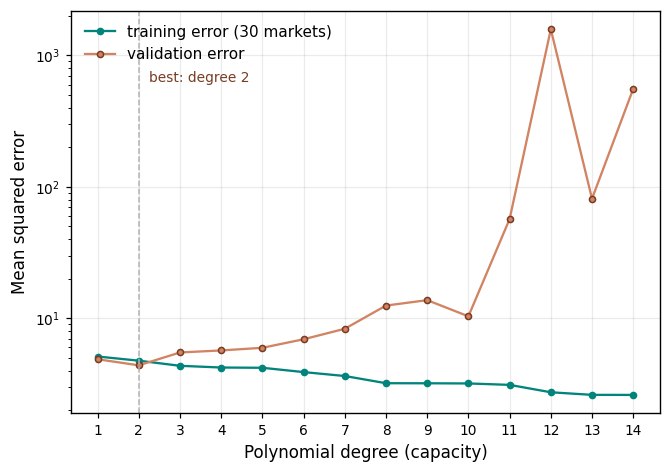

 degree   train MSE     val MSE
      1       5.119        4.88
      2       4.758        4.39   <-- chosen
      3       4.350        5.49
      4       4.221        5.69
      5       4.202        5.96
      6       3.897        6.92
      7       3.638        8.32
      8       3.207       12.50
      9       3.202       13.74
     10       3.193       10.35
     11       3.115       56.87
     12       2.736     1579.11
     13       2.615       81.17
     14       2.613      556.18


In [13]:
# A deliberately small training set, so that capacity has something to exploit.
sub = rng.choice(len(x_train), size=30, replace=False)
x_small, y_small = x_train[sub], y_train[sub]

xsm_s = (x_small - mu) / sigma
xva_s = (x_val   - mu) / sigma
xte_s = (x_test  - mu) / sigma

degrees = np.arange(1, 15)
train_mse, val_mse = [], []
for d in degrees:
    coeffs = np.polyfit(xsm_s, y_small, d)
    train_mse.append(mean_squared_error(y_small, np.polyval(coeffs, xsm_s)))
    val_mse.append(mean_squared_error(y_val,     np.polyval(coeffs, xva_s)))

best_d = int(degrees[int(np.argmin(val_mse))])

fig, ax = plt.subplots(figsize=(6.2, 4.4))
ax.plot(degrees, train_mse, '-o', color=TEAL, ms=4, label='training error (30 markets)')
ax.plot(degrees, val_mse, '-o', color=ORANGE, mec=ODGE, ms=4, label='validation error')
ax.axvline(best_d, color=GREY, ls='--', lw=1)
ax.text(best_d + 0.25, max(val_mse) * 0.4, f'best: degree {best_d}', fontsize=9, color=ODGE)
ax.set_xlabel('Polynomial degree (capacity)')
ax.set_ylabel('Mean squared error')
ax.set_yscale('log')
ax.set_xticks(degrees)
ax.legend(frameon=False, loc='upper left')
ax.grid(alpha=0.25)
plt.tight_layout(); plt.show()

print(f"{'degree':>7}  {'train MSE':>10}  {'val MSE':>10}")
for d, t, v in zip(degrees, train_mse, val_mse):
    flag = '   <-- chosen' if d == best_d else ''
    print(f"{d:7d}  {t:10.3f}  {v:10.2f}{flag}")

There it is.

**The training error only ever goes down.** Adding parameters can never make the fit to the training data worse, so that curve carries no information whatsoever about whether the model is any good. A researcher who reports only this number has reported nothing.

**The validation error goes down, reaches a minimum, and then climbs steeply**, ending two orders of magnitude above where it started. Everything to the left of the minimum is **underfitting**: the model is too rigid to represent the pattern. Everything to the right is **overfitting**: the model has enough freedom to bend toward individual training points, and those bends are fitted to noise, which by definition does not repeat in new data.

Look at the vertical axis, which is logarithmic. A degree 14 polynomial through 30 points is not slightly worse than a quadratic. It is catastrophically worse, while looking better on every number you had before you held data back.

Keep this curve in mind, because in Chapter 8 it will stop behaving. Very large networks, with far more parameters than data points, often keep improving well past the point where this picture says they should collapse. Explaining why is an open research question, and one of the more interesting things about the field you are studying.

### 4.3 Now, and only now, the test set

We used validation error to make one decision: the polynomial degree. That decision is made. We can open the test set exactly once.

Chosen model: polynomial of degree 2, fitted on 30 markets
  train MSE      =   4.758
  validation MSE =   4.387
  test MSE       =   6.885   <-- the number you report


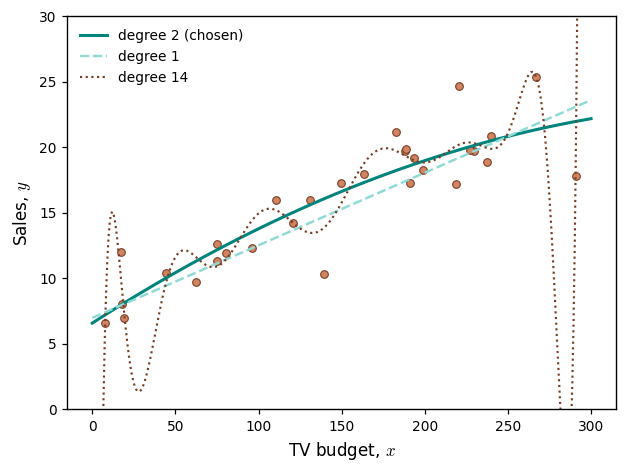

In [14]:
coeffs = np.polyfit(xsm_s, y_small, best_d)
test_pred = np.polyval(coeffs, xte_s)

print(f"Chosen model: polynomial of degree {best_d}, fitted on 30 markets")
print(f"  train MSE      = {mean_squared_error(y_small, np.polyval(coeffs, xsm_s)):7.3f}")
print(f"  validation MSE = {mean_squared_error(y_val,   np.polyval(coeffs, xva_s)):7.3f}")
print(f"  test MSE       = {mean_squared_error(y_test,  test_pred):7.3f}   <-- the number you report")

grid = np.linspace(0, 300, 400)
grid_s = (grid - mu) / sigma
worst = np.polyfit(xsm_s, y_small, 14)

fig, ax = plt.subplots(figsize=(5.8, 4.4))
scatter(ax, x_small, y_small, ms=5)
ax.plot(grid, np.polyval(coeffs, grid_s), color=TEAL, lw=2, label=f'degree {best_d} (chosen)')
ax.plot(grid, phi0_star + phi1_star * grid, color=LTEAL, lw=1.6, ls='--', label='degree 1')
ax.plot(grid, np.polyval(worst, grid_s), color=ODGE, lw=1.4, ls=':', label='degree 14')
ax.set_xlabel('TV budget, $x$'); ax.set_ylabel('Sales, $y$')
ax.set_ylim(0, 30)
ax.legend(frameon=False, fontsize=9)
plt.tight_layout(); plt.show()

The dotted degree 14 curve is what overfitting looks like when you draw it. It passes very close to the 30 training points and does something indefensible everywhere in between.

The chosen model, by contrast, is modest. It bends gently to catch the flattening at high budgets, which is a real effect and roughly what an economist would predict from diminishing returns. It does not wander.

The validation error picked that on its own, from a menu that included degree 14. Nobody had to look at the answer.

---
## 5. Classification, and a model with nothing to learn

The lecture defined a classification problem as supervised learning where $y$ is a discrete label rather than a number. The Iris dataset is the standard first example: four flower measurements, three species, 150 plants.

We use two of the four measurements so the picture fits on a page.

In [15]:
try:
    iris = pd.read_csv(find_data('iris.csv'))
    feat = ['PetalLength[cm]', 'PetalWidth[cm]']
    Xi = iris[feat].to_numpy(dtype=float)
    yi_names = iris['Species'].to_numpy()
    classes = sorted(set(yi_names))
    yi = np.array([classes.index(s) for s in yi_names])
except FileNotFoundError:
    from sklearn.datasets import load_iris
    d = load_iris()
    Xi = d.data[:, 2:4]
    yi = d.target
    classes = list(d.target_names)
    feat = ['petal length (cm)', 'petal width (cm)']

print(f"{Xi.shape[0]} flowers, {Xi.shape[1]} features, {len(classes)} classes")
print(classes)

Xi_tr, Xi_te, yi_tr, yi_te = train_test_split(
    Xi, yi, test_size=0.25, random_state=0, stratify=yi)
print(f"train {len(yi_tr)}, test {len(yi_te)}")

150 flowers, 2 features, 3 classes
['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
train 112, test 38


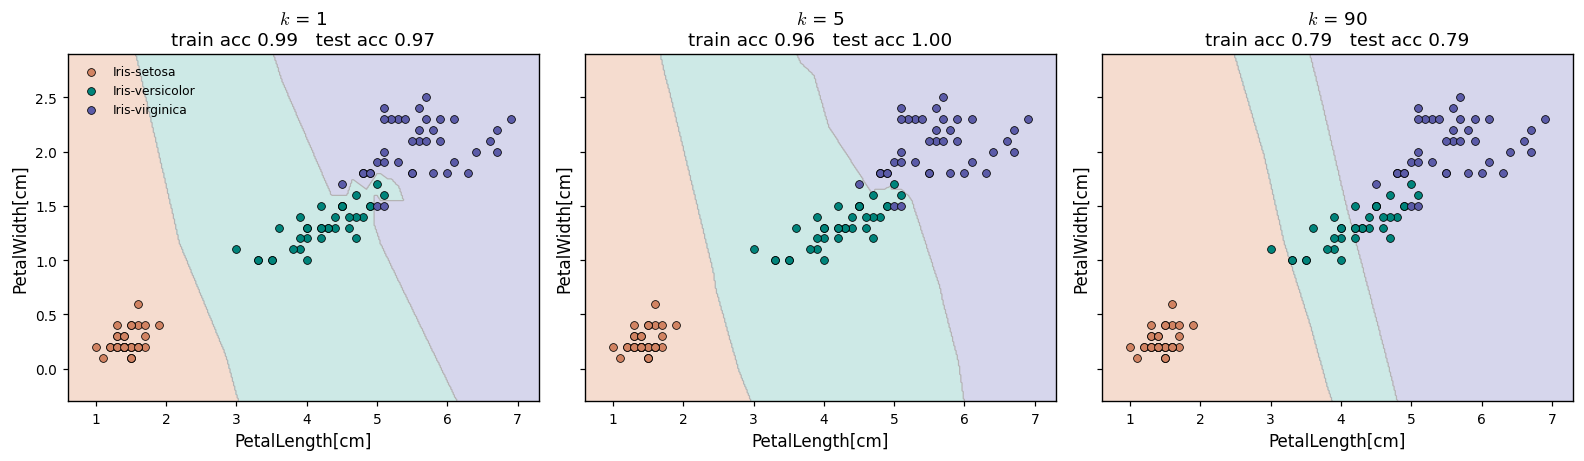

In [16]:
from matplotlib.colors import ListedColormap

CMAP_PTS  = ListedColormap([ORANGE, TEAL, '#5B5BA8'])
CMAP_FILL = ListedColormap(['#F5DCCF', '#CDE9E6', '#D6D6EC'])

def plot_decision_regions(clf, X, y, ax, title=''):
    """Draw a 2D classifier's decision regions. Replaces mlxtend's version
    so the notebook needs no extra dependency."""
    pad = 0.4
    xx, yy = np.meshgrid(
        np.linspace(X[:, 0].min() - pad, X[:, 0].max() + pad, 400),
        np.linspace(X[:, 1].min() - pad, X[:, 1].max() + pad, 400))
    Zg = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Zg, alpha=1.0, cmap=CMAP_FILL, levels=[-0.5, 0.5, 1.5, 2.5])
    ax.contour(xx, yy, Zg, colors=[GREY], linewidths=0.8, levels=[0.5, 1.5])
    for c in np.unique(y):
        ax.scatter(X[y == c, 0], X[y == c, 1], s=26, edgecolor='k', linewidth=0.5,
                   color=CMAP_PTS(c), label=classes[c], zorder=3)
    ax.set_xlabel(feat[0]); ax.set_ylabel(feat[1])
    ax.set_title(title)

fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.3), sharey=True)
for k, ax in zip([1, 5, 90], axes):
    knn = KNeighborsClassifier(n_neighbors=k).fit(Xi_tr, yi_tr)
    acc_tr = accuracy_score(yi_tr, knn.predict(Xi_tr))
    acc_te = accuracy_score(yi_te, knn.predict(Xi_te))
    plot_decision_regions(knn, Xi_tr, yi_tr, ax,
                          title=f"$k$ = {k}\ntrain acc {acc_tr:.2f}   test acc {acc_te:.2f}")
axes[0].legend(frameon=False, fontsize=8, loc='upper left')
plt.tight_layout(); plt.show()

The same capacity story, in two dimensions.

At $k=1$ the boundary is jagged and carves out little islands around individual points. Training accuracy is 0.99, higher than the test accuracy of 0.97. The model is fitting the training set more closely than the underlying pattern warrants.

At $k=5$ the boundary is smooth, and the model does as well as anything can on this data.

At $k=90$ it has collapsed. A neighbourhood of 90 out of 112 training flowers covers most of the dataset, so the average is taken over flowers of every species and the model loses the ability to distinguish them. Both scores fall together, which is the signature of underfitting: unlike overfitting, it is visible in the training score alone.

**Now the point that makes this section worth the time.**

This classifier has **no parameters**. Nothing was optimised. There is no $\boldsymbol{\phi}$, no loss function, no gradient descent, and "training" consisted of copying the training set into memory. Yet at $k=5$ it classifies these flowers perfectly.

So why does the rest of this course spend fourteen weeks on models that do have parameters?

- **Cost at prediction time.** To classify one new flower, $k$-NN measures its distance to every stored training point. A model with parameters does its work once, during training, and prediction afterwards is cheap. For a model serving millions of requests, this difference decides whether the thing can exist at all.
- **Storage.** $k$-NN must keep the entire training set forever. A trained network keeps only $\boldsymbol{\phi}$, which is usually far smaller than the data it was trained on.
- **Dimensionality.** Two features and a clean separation is the best case. In a thousand dimensions, "nearest" stops meaning very much: distances concentrate, and every point becomes roughly equidistant from every other. Images and text live in exactly those dimensions.
- **No learned representation.** $k$-NN compares raw measurements. It cannot discover that some combination of the inputs matters more than the inputs themselves. Most of this course's power comes from models that learn *what to measure* before they classify, and that is the subject of Chapter 3.

Parameters are not free; they have to be fitted, and fitting them is the hard part. What they buy is compression, speed, and a learned representation. Keep that trade in mind when the next lecture introduces a model with thousands of them.

---
## 6. What changes from here

Everything in this notebook shared one property: the loss surface had a single minimum, and we could either compute the answer directly or reach it reliably by walking downhill.

Starting with shallow neural networks in the next lecture, three of those comforts disappear at once:

| | Here | From Chapter 3 on |
|---|---|---|
| Closed-form solution | exists (least squares) | none |
| Loss surface | convex, one minimum | many minima and saddle points |
| Number of parameters | 2 to 15 | thousands to billions |
| How you fit it | direct formula, or gradient descent | gradient descent, and nothing else |

What does *not* change is the vocabulary. Model, parameters, loss, training set, validation set, test set, underfitting, overfitting. Every one of those terms means in Chapter 20 exactly what it meant in this notebook. The models get vastly more expressive; the framework you just used stays put.

---
## 7. Exercises

Work through these before the next lecture. They are short, and each one targets something that will otherwise bite you later.

**1. Multiple inputs.** The advertising dataset has three budgets, not one. Fit `LinearRegression` on all three columns and compare test MSE to the TV-only model. Look at `lin.coef_`: what does the newspaper coefficient suggest? Be careful with your conclusion, because the three budgets are correlated with each other.

**2. Find the edge of stability.** In Section 2, run `gradient_descent` on the *standardised* input with learning rates of 0.01, 0.1, 0.5, 1.0, and 1.05. Plot the training curves together. Locate roughly where convergence turns into divergence, and describe the behaviour just below that boundary.

**3. How much data hides overfitting?** Rerun Section 4.2 with `size=` set to 15, 30, 60, and all 120 training markets. Plot the four validation curves together. At what point does the upturn become invisible, and what does that tell you about how much you can trust a flat-looking curve?

**4. How noisy is one split?** Rerun Section 3 with `random_state` set to 0 through 19, collecting the test MSE each time. Report the mean and standard deviation. Is a single reported test number something you would trust to three decimal places?

**5. The cost of peeking.** Redo Section 4.2, but choose the polynomial degree by *test* error rather than validation error, and then report that test error as your result. Compare it to the honest number from Section 4.3. How much did you flatter yourself, and why is the gap not zero?

**6. Scaling and distance.** In Section 5, multiply petal length by 100 before fitting the $k$-NN classifier, and refit. Accuracy should collapse. Explain precisely why, in terms of how $k$-NN computes distance. Then explain why this specific failure does *not* happen to `LinearRegression`.

**7. Back to the toy problem.** Return to Prince's `2_1_Supervised_Learning.ipynb` and apply the `gradient_descent` function from Section 2 to his twelve points. Does it find the optimum he reports at $(0.826, 0.522)$? Did you need to standardise the input, and if not, why not?